In [1]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import h5py

from vgh_2d import WfnParams, Wavefunction, HamiltParams, eom, energy

In [137]:
def get_e_vgh_for_coupling(dir,init,Mx,My,tx,ty,qx,qy,B,V_0_arr):
    e_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_T_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_V_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_B_arr = np.zeros(len(V_0_arr), dtype=complex)

    Tx_arr = np.zeros(len(V_0_arr), dtype=complex)
    Ty_arr = np.zeros(len(V_0_arr), dtype=complex)

    for i in range(len(V_0_arr)):
        V_0 = V_0_arr[i]
        file_path = dir+'data_'+str(init)+'_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_qx_'+str(qx)+'_qy_'+str(qy)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'

        with h5py.File(file_path, 'r') as f:
            phi_data = f["wfn"][...]
            Mx = f["Mx"][...]
            My = f["My"][...]
            n = f["n"][...]
            B = f["B"][...]
            tx = f["tx"][...]
            ty = f["ty"][...]
            qx = f["qx"][...]
            qy = f["qy"][...]
            V_0 = f["V0"][...]

        params = {"n": n, "Mx": Mx, "My": My, "B": B, "tx": tx, "ty": ty, "V_0": V_0, "qx": qx, "qy": qy}

        energy_object = energy(params=params)
        E = energy_object.calc_energy(phi_data)
        Tx, Ty = energy_object.deriv_dE_dt(phi_data)

        e_arr[i] = E[0] 
        e_T_arr[i] = E[1]
        e_B_arr[i] = E[2]
        e_V_arr[i] = E[3]
        
        Tx_arr[i] = Tx
        Ty_arr[i] = Ty

    return e_arr, e_T_arr, e_B_arr, e_V_arr, Tx, Ty

def get_state_e_vgh_data(dir,Mx,My,tx_arr,ty_arr,qx,qy,B,V_0_arr):
    e_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)

    e_T_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    e_B_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    e_V_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    
    Tx_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    Ty_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    for i in range(len(tx_arr)):
        tx = tx_arr[i]
        ty = ty_arr[i]

        init = 'uniform'
        e_flp, e_flp_T, e_flp_B, e_flp_V, Tx_flp, Ty_flp = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        init = 'fdv'
        e_fdv, e_fdv_T, e_fdv_B, e_fdv_V, Tx_fdv, Ty_fdv = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        init = 'fdh'
        e_fdh, e_fdh_T, e_fdh_B, e_fdh_V, Tx_fdh, Ty_fdh = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        init = 'sp'
        e_sp, e_sp_T, e_sp_B, e_sp_V, Tx_sp, Ty_sp = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        e_arr[0,i] = e_flp
        e_arr[1,i] = e_fdv
        e_arr[2,i] = e_fdh
        e_arr[3,i] = e_sp

        e_T_arr[0,i] = e_flp_T
        e_T_arr[1,i] = e_fdv_T
        e_T_arr[2,i] = e_fdh_T
        e_T_arr[3,i] = e_sp_T

        e_B_arr[0,i] = e_flp_B
        e_B_arr[1,i] = e_fdv_B
        e_B_arr[2,i] = e_fdh_B
        e_B_arr[3,i] = e_sp_B
        
        e_V_arr[0,i] = e_flp_V
        e_V_arr[1,i] = e_fdv_V
        e_V_arr[2,i] = e_fdh_V
        e_V_arr[3,i] = e_sp_V

        Tx_arr[0,i] = Tx_flp
        Tx_arr[1,i] = Tx_fdv
        Tx_arr[2,i] = Tx_fdh
        Tx_arr[3,i] = Tx_sp

        Ty_arr[0,i] = Ty_flp
        Ty_arr[1,i] = Ty_fdv
        Ty_arr[2,i] = Ty_fdh
        Ty_arr[3,i] = Ty_sp

    return e_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr

def get_Px_Py(dir,init,Mx,My,tx,ty,qx,qy,B,V_0):
    file_path = dir+'data_'+str(init)+'_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_qx_'+str(qx)+'_qy_'+str(qy)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'

    with h5py.File(file_path, 'r') as f:
        phi_data = f["wfn"][...]
        Mx = f["Mx"][...]
        My = f["My"][...]
        n = f["n"][...]
        B = f["B"][...]
        tx = f["tx"][...]
        ty = f["ty"][...]
        qx = f["qx"][...]
        qy = f["qy"][...]
        V_0 = f["V0"][...]

    wfnpar = WfnParams(Mx, My, n)
    Mx, My, n, x, k2 = wfnpar.read()

    P_arr = np.zeros((My,Mx), dtype=complex)
    Px_arr = np.zeros((My,Mx), dtype=complex)
    Py_arr = np.zeros((My,Mx), dtype=complex)
    for i in range(My):
        for j in range(Mx):
            Px = np.sum(np.cos(x)*np.abs(phi_data[i,j,:])**2) 
            Py = np.sum(np.sin(x)*np.abs(phi_data[i,j,:])**2)

            P_arr[i,j] = (Px**2 + Py**2)**0.5
            Px_arr[i,j] = Px
            Py_arr[i,j] = Py

    return P_arr, Px_arr, Py_arr

def get_Px_Py_4_states(dir,init,Mx,My,tx,ty,qx,qy,B,V_0):
    init = 'uniform'
    P_flp, Px_flp, Py_flp = get_Px_Py(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

    init = 'fdv'
    P_fdv, Px_fdv, Py_fdv = get_Px_Py(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

    init = 'fdh'
    P_fdh, Px_fdh, Py_fdh = get_Px_Py(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

    init = 'sp'
    P_sp, Px_sp, Py_sp = get_Px_Py(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

    P = [P_flp, P_fdv, P_fdh, P_sp]
    Px = [Px_flp, Px_fdv, Px_fdh, Px_sp]
    Py = [Py_flp, Py_fdv, Py_fdh, Py_sp]
    
    return P, Px, Py

def outfold_array(psi):
    My = psi.shape[0]
    Mx = psi.shape[1]
    
    psi_n = psi.copy()
    for i in range(My):
        for j in range(Mx):
            psi_ij = psi[(i+int(My/2))%My,(j+int(Mx/2))%Mx] 
            psi_n[i,j] = psi_ij
    return psi_n

# Energy Characteristics

In [7]:
'''
Example Test for one delta_t value, i.e. one lattice symmetry
'''
V_0_arr = np.array([0.7])

Mx = 5
My = 5
tx = 0.5
ty = 0.5
B = 1e-2

qx=0.0
qy=0.0

init = 'sp'
dir_sym = 'data_vgh/'
e, e_T, e_B, e_V, Tx, Ty = get_e_vgh_for_coupling(dir=dir_sym,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

print('E     =', e, '\nE_T   =', e_T, '\nE_B   =', e_B, '\nE_V   =', e_V, '\nTx    =', Tx, '\nTy    =', Ty)

E     = [-2.56599196-6.01284407e-20j] 
E_T   = [-0.00011894-1.20370622e-34j] 
E_B   = [0.11545524-6.01284407e-20j] 
E_V   = [-2.68132826+0.j] 
Tx    = (-0.00011894043428609089-9.62964972193618e-35j) 
Ty    = (-0.00011894043428609412-1.4444474582904269e-34j)


In [5]:
'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr = np.array([0.7])

Mx = 5
My = 5
tx_arr = np.array([0.5])
ty_arr = np.array([0.5])
B = 1e-2

qx=0.0
qy=0.0

dir='data_vgh/'
e_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr = get_state_e_vgh_data(dir=dir,Mx=Mx,My=My,tx_arr=tx_arr,ty_arr=ty_arr,qx=qx,qy=qx,B=B,V_0_arr=V_0_arr)

tx = 0.5  ty = 0.5


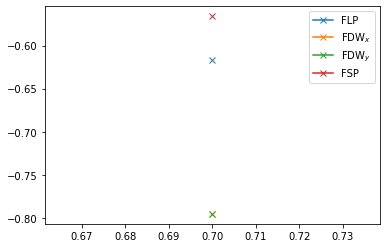

In [6]:
delta_t_index = 0
print('tx =', tx_arr[delta_t_index], ' ty =', ty_arr[delta_t_index])

plt.plot(V_0_arr, e_arr[0,delta_t_index].real+2, marker='x', label=r'FLP')
plt.plot(V_0_arr, e_arr[2,delta_t_index].real+2, marker='x', label=r'FDW$_x$')
plt.plot(V_0_arr, e_arr[1,delta_t_index].real+2, marker='x', label=r'FDW$_y$')
plt.plot(V_0_arr, e_arr[3,delta_t_index].real+2, marker='x', label=r'FSP')

plt.legend()

# Wavefunction Characteristics
## Polarization

In [140]:
'''
Get Polarization of Single Wavefunction
'''
V_0 = 0.7

Mx = 6
My = 6
tx_arr = 0.5
ty_arr = 0.5
B = 1e-2

qx=0.0
qy=0.0

init = 'fdv'
dir='data_vgh/'
P, Px, Py = get_Px_Py(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

print('P_max =', np.max(P), ', P_min =', np.min(P), ', P_arr shape:', P.shape)

P_max = (0.8900343501040479+0j) , P_min = (8.485972208701487e-17+0j) , P_arr shape: (6, 6)


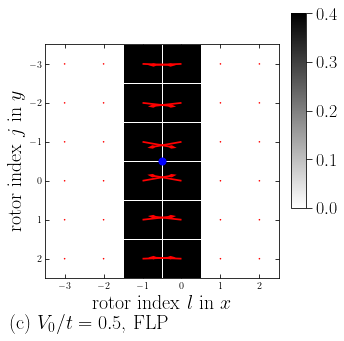

In [141]:
P_plot = P
Px_plot = Px
Py_plot = Py

x_arr = np.arange(-int(Px_plot.shape[0]/2),int(Px_plot.shape[0]/2),1)
X, Y = np.meshgrid(x_arr, x_arr) # np.meshgrid(np.arange(-4,5,1), np.arange(-4,5,1))


A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20

fig, ax = plt.subplots(figsize=[4,4]) #[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)]) #, subplot_kw={"projection": "3d"})
ax.set_aspect("equal")

#plt.title(r'FO, $B=0.5\cdot 10^{-2}t$', fontsize=font_size)

'''Polarization Absolute Value'''
pc = plt.pcolormesh(X, Y, outfold_array(P_plot.real), cmap='binary', vmin=0.0, vmax=0.4, snap=True)#, facecolors='none') # norm=matplotlib.colors.LinNorm(vmin=0.1, vmax=1))

cax = ax.inset_axes([2.8, -4.3, 0.4, 5], transform=ax.transData)
cbar = fig.colorbar(pc, shrink=0.6, cax=cax, orientation='vertical') #, orientation="horizontal", pad=0.2)
cbar.ax.tick_params(length=6, labelsize=18)
#cbar.set_ticks(ticks=[0, 1, 2], labels=['0','1','2'])
#cbar.set_label(label=r'$\sigma^2_{\phi}/\sigma^2_0$', size=font_size)
cbar.solids.set_rasterized(True)
#pc.set_edgecolor('face')
pc.set_edgecolor('white')

'''Polarization Vector Plot'''
q = plt.quiver(X, Y, outfold_array(Px_plot), outfold_array(Py_plot), color='red', scale=6, headlength=3, headwidth=2)
ax.invert_yaxis()

ax.scatter(-0.5, -0.5, marker='o', s=50, color='blue', alpha=1, zorder=2)
ax.annotate(r'(c) $V_0/t=0.5$, FLP', xy=(0.2, -0.1), xytext=(-4.4, 3.8), fontsize=20, color='black')

plt.xlabel(r'rotor index $l$ in $x$', fontsize=font_size)
plt.ylabel(r'rotor index $j$ in $y$', fontsize=font_size)

#plt.xticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)
#plt.yticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)

#plt.xlim(-5,5)
#plt.ylim(-5,5)

plt.tick_params(axis='x', direction='in', length=4, top=True)
plt.tick_params(axis='y', direction='in', length=4, right=True)
plt.tick_params(which='minor', axis='x', direction='in', top=True)
plt.tick_params(which='minor', axis='y', direction='in', right=True)

ax.set_aspect(1)
fig.set_size_inches(4.3, 4.3, forward=True)

#plt.savefig('results/configurations/pol_size/p_vec_fo.svg')

In [22]:
'''
Get Polarization for 4 States
'''
V_0 = 0.7

Mx = 5
My = 5
tx_arr = 0.5
ty_arr = 0.5
B = 1e-2

qx=0.0
qy=0.0

dir='data_vgh/'
P, Px, Py = get_Px_Py_4_states(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

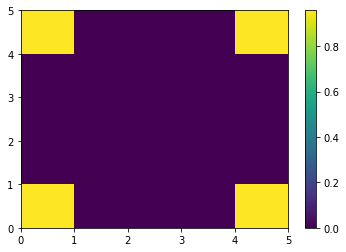

In [27]:
pc = plt.pcolormesh(P[3].real)
plt.colorbar(pc)
plt.show()